# Notebook 01 — Data Download and Preprocessing
**Thesis: Computer Vision and Deep Learning for Real-Time Quality Inspection in Manufacturing**

## Overview
Prepares three industrial defect datasets for a **dual-pipeline** system:

| Pipeline | Model | Format Needed |
|----------|-------|---------------|
| A — Detection | YOLOv8 | YOLO `.txt` labels + `data.yaml` |
| B — Classification | ResNet50 / EfficientNet-B0 / MobileNetV3 | ImageFolder directories |

## Datasets
| Dataset | Classes | Images | Annotation |
|---------|---------|--------|-----------|
| NEU-DET | 6 defect types | ~1800 | PASCAL VOC XML bounding boxes |
| DAGM 2007 | binary defect/no-defect | ~7000 (classes 1–6) | Mask → derived bbox |
| KSDD2 | binary defect/no-defect | ~3335 | Pixel mask → derived bbox |

## Drive Outputs
```
MyDrive/thesis_project/
├── datasets/{NEU-DET,DAGM,KSDD2}/
│   ├── images/{train,val,test}/          ← YOLO detection images
│   ├── labels/{train,val,test}/          ← YOLO .txt label files
│   ├── classification/{train,val,test}/{class_name}/  ← CNN ImageFolder
│   └── data.yaml                         ← YOLO training config
├── dataset_metadata/
│   ├── neu_detection_splits.csv
│   ├── neu_classification_splits.csv
│   ├── dagm_splits.csv
│   ├── ksdd2_splits.csv
│   ├── ksdd2_class_weights.json
│   └── dataset_statistics.csv
├── results/figures/FIG_SampleGrid_*.png
└── checkpoints/notebook01_status.json
```

**Split:** 70 / 15 / 15 (stratified)  
**Seed:** 42 everywhere  
**Runtime:** ~25–40 minutes on Colab T4  
**Prerequisite:** Upload `kaggle.json` before running Section 0-C

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0-A: Install dependencies
# ═══════════════════════════════════════════════════════════════════════════════
!pip install -q ultralytics kaggle opencv-python-headless tqdm pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.1 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0-B: Mount Drive + create full directory tree + set seeds
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, random, shutil, json, subprocess, pathlib
import numpy as np
import torch

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Base path ─────────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/thesis_project'

# ── Create full Drive directory tree ─────────────────────────────────────────
DIRS = [
    # NEU-DET
    f'{BASE}/datasets/NEU-DET/images/train',
    f'{BASE}/datasets/NEU-DET/images/val',
    f'{BASE}/datasets/NEU-DET/images/test',
    f'{BASE}/datasets/NEU-DET/labels/train',
    f'{BASE}/datasets/NEU-DET/labels/val',
    f'{BASE}/datasets/NEU-DET/labels/test',
    f'{BASE}/datasets/NEU-DET/classification/train',
    f'{BASE}/datasets/NEU-DET/classification/val',
    f'{BASE}/datasets/NEU-DET/classification/test',
    # DAGM
    f'{BASE}/datasets/DAGM/images/train',
    f'{BASE}/datasets/DAGM/images/val',
    f'{BASE}/datasets/DAGM/images/test',
    f'{BASE}/datasets/DAGM/labels/train',
    f'{BASE}/datasets/DAGM/labels/val',
    f'{BASE}/datasets/DAGM/labels/test',
    f'{BASE}/datasets/DAGM/classification/train',
    f'{BASE}/datasets/DAGM/classification/val',
    f'{BASE}/datasets/DAGM/classification/test',
    # KSDD2
    f'{BASE}/datasets/KSDD2/images/train',
    f'{BASE}/datasets/KSDD2/images/val',
    f'{BASE}/datasets/KSDD2/images/test',
    f'{BASE}/datasets/KSDD2/labels/train',
    f'{BASE}/datasets/KSDD2/labels/val',
    f'{BASE}/datasets/KSDD2/labels/test',
    f'{BASE}/datasets/KSDD2/classification/train',
    f'{BASE}/datasets/KSDD2/classification/val',
    f'{BASE}/datasets/KSDD2/classification/test',
    # Metadata
    f'{BASE}/dataset_metadata',
    # Models
    f'{BASE}/models/yolo/full',
    f'{BASE}/models/yolo/onnx',
    f'{BASE}/models/yolo/tflite',
    f'{BASE}/models/yolo/tensorrt',
    f'{BASE}/models/yolo/quantized',
    f'{BASE}/models/yolo/pruned',
    f'{BASE}/models/cnn/full',
    f'{BASE}/models/cnn/onnx',
    f'{BASE}/models/cnn/tflite',
    f'{BASE}/models/cnn/quantized',
    f'{BASE}/models/cnn/pruned',
    f'{BASE}/models/combined',
    # Training logs
    f'{BASE}/training_logs/yolo',
    f'{BASE}/training_logs/cnn',
    f'{BASE}/training_logs/tensorboard',
    # Results
    f'{BASE}/results/figures',
    f'{BASE}/results/tables',
    f'{BASE}/results/tensorrt_benchmarks',
    f'{BASE}/results/logs',
    # Checkpoints
    f'{BASE}/checkpoints',
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

print(f'Seed = {SEED}')
print(f'Base = {BASE}')
print(f'Directory tree created ({len(DIRS)} dirs).')

Mounted at /content/drive
Seed = 42
Base = /content/drive/MyDrive/thesis_project
Directory tree created (48 dirs).


In [ ]:
from google.colab import files
files.upload() # This will open a file picker; select your kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"likithjayaramgowda","key":"e340b30b35bb850fd731645515438f7f"}'}

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0-C: Kaggle API setup
# ═══════════════════════════════════════════════════════════════════════════════
# Option A (recommended): Place kaggle.json in Drive, set the path below
# Option B: Upload manually via Files panel → /root/.kaggle/kaggle.json
# Option C: Set KAGGLE_USERNAME and KAGGLE_KEY as Colab secrets

KAGGLE_JSON_DRIVE = '/content/drive/MyDrive/thesis_project/kaggle.json'

import stat

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_dest = f'{kaggle_dir}/kaggle.json'

if KAGGLE_JSON_DRIVE and os.path.exists(KAGGLE_JSON_DRIVE):
    shutil.copy(KAGGLE_JSON_DRIVE, kaggle_dest)
    os.chmod(kaggle_dest, 0o600)
    print('Kaggle credentials loaded from Drive.')
elif os.path.exists(kaggle_dest):
    print('kaggle.json already in place.')
elif os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', kaggle_dest)
    os.chmod(kaggle_dest, 0o600)
    print('Kaggle credentials loaded from /content/.')
else:
    print('WARNING: kaggle.json not found.')
    print('Upload it via Files panel or use: from google.colab import files; files.upload()')

Kaggle credentials loaded from Drive.


---
# Section 1 — NEU-DET Surface Defect Database

- **6 classes:** `crazing`, `inclusion`, `patches`, `pitted_surface`, `rolled_in_scale`, `scratched`
- **~1800 images** (~300/class), 200×200 px, grayscale
- **Annotations:** PASCAL VOC XML files (`.xml` per image with `<bndbox>` elements)
- **Detection output:** YOLO `.txt` labels (class_id x_center y_center w h, normalized)
- **Classification output:** Full image + per-bbox crops in ImageFolder dirs
- **Split:** 70/15/15 stratified by dominant class

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1-A: Download NEU-DET
# ═══════════════════════════════════════════════════════════════════════════════
NEU_RAW   = '/content/neu_raw'
NEU_DRIVE = f'{BASE}/datasets/NEU-DET'

# Checkpoint: skip if already processed
if os.path.exists(f'{NEU_DRIVE}/data.yaml'):
    print('NEU-DET already processed. Skipping download.')
    NEU_DONE = True
else:
    NEU_DONE = False
    os.makedirs(NEU_RAW, exist_ok=True)

    # Try multiple Kaggle slugs
    NEU_SLUGS = [
        'kaustubhdikshit/neu-surface-defect-database',
        'fantacher/neu-det',
        'ramesha/neu-surface-defect-database-with-bounding-boxes',
    ]

    downloaded = False
    for slug in NEU_SLUGS:
        print(f'Trying: {slug} ...')
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', slug, '-p', NEU_RAW, '--unzip'],
            capture_output=True, text=True, timeout=300
        )
        if r.returncode == 0:
            print(f'  Downloaded OK')
            downloaded = True
            break
        print(f'  Failed: {r.stderr.strip()[-150:]}')

    if not downloaded:
        print('\nManual download required:')
        print('1. Search Kaggle for "NEU-DET bounding box"')
        print(f'2. Unzip to: {NEU_RAW}')
        print('3. Expected structure: Class folders or images/ + annotations/ folders')
        raise RuntimeError('NEU-DET download failed')

    print('\nDownloaded files (first 20):')
    for p in sorted(pathlib.Path(NEU_RAW).rglob('*'))[:20]:
        print(' ', p.relative_to(NEU_RAW))

NEU-DET already processed. Skipping download.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1-B: Parse NEU-DET — XML annotations → YOLO format
# ═══════════════════════════════════════════════════════════════════════════════
if not NEU_DONE:
    import xml.etree.ElementTree as ET
    import cv2
    from collections import Counter

    NEU_CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface',
                   'rolled_in_scale', 'scratched']
    CLS2IDX = {c: i for i, c in enumerate(NEU_CLASSES)}

    def parse_voc_xml(xml_path):
        """Parse PASCAL VOC XML → list of (cls_id, xc, yc, bw, bh, cls_name, x1, y1, x2, y2)."""
        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find('size')
        iw = int(size.find('width').text)
        ih = int(size.find('height').text)
        boxes = []
        for obj in root.findall('object'):
            name = obj.find('name').text.strip().lower()
            # Normalize name variants
            name = name.replace('-', '_').replace(' ', '_')
            if name == 'rolled_in_scale':
                pass
            elif name == 'pitted_surface':
                pass
            # Find closest match
            matched = name if name in CLS2IDX else None
            if matched is None:
                for c in NEU_CLASSES:
                    if c in name or name in c:
                        matched = c
                        break
            if matched is None:
                continue
            bb = obj.find('bndbox')
            x1 = max(0.0, float(bb.find('xmin').text))
            y1 = max(0.0, float(bb.find('ymin').text))
            x2 = min(float(iw), float(bb.find('xmax').text))
            y2 = min(float(ih), float(bb.find('ymax').text))
            if x2 <= x1 or y2 <= y1:
                continue
            xc = (x1 + x2) / 2 / iw
            yc = (y1 + y2) / 2 / ih
            bw = (x2 - x1) / iw
            bh = (y2 - y1) / ih
            boxes.append((CLS2IDX[matched], xc, yc, bw, bh, matched,
                          int(x1), int(y1), int(x2), int(y2)))
        return boxes, iw, ih

    raw_path = pathlib.Path(NEU_RAW)
    all_imgs = (list(raw_path.rglob('*.jpg')) + list(raw_path.rglob('*.bmp')) +
                list(raw_path.rglob('*.png')))
    all_xmls = list(raw_path.rglob('*.xml'))

    print(f'Found {len(all_imgs)} images, {len(all_xmls)} XML files')

    xml_by_stem = {x.stem: x for x in all_xmls}
    img_by_stem = {}
    for img in all_imgs:
        if img.stem not in img_by_stem:
            img_by_stem[img.stem] = img

    parsed_samples = []
    synthetic_count = 0

    for stem, img_path in img_by_stem.items():
        if stem in xml_by_stem:
            try:
                boxes, iw, ih = parse_voc_xml(xml_by_stem[stem])
            except Exception as e:
                print(f'  XML parse error {stem}: {e}')
                continue
        else:
            # No XML: infer class from path, generate synthetic bbox
            matched_cls = None
            path_str = str(img_path).lower()
            for c in NEU_CLASSES:
                if c in path_str:
                    matched_cls = c
                    break
            if matched_cls is None:
                continue
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            ih, iw = img.shape[:2]
            # Synthetic bbox: 80% of image centered
            boxes = [(CLS2IDX[matched_cls], 0.5, 0.5, 0.8, 0.8, matched_cls,
                      int(0.1*iw), int(0.1*ih), int(0.9*iw), int(0.9*ih))]
            synthetic_count += 1

        if not boxes:
            continue

        dominant = Counter(b[5] for b in boxes).most_common(1)[0][0]
        parsed_samples.append({
            'stem': stem, 'img_path': str(img_path),
            'boxes': boxes, 'dominant_class': dominant,
        })

    print(f'Parsed {len(parsed_samples)} samples (synthetic bboxes: {synthetic_count})')
    class_dist = Counter(s['dominant_class'] for s in parsed_samples)
    for c, n in sorted(class_dist.items()):
        print(f'  {c}: {n}')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1-C: NEU-DET — stratified split + write detection + classification files
# ═══════════════════════════════════════════════════════════════════════════════
if not NEU_DONE:
    import cv2, pandas as pd
    from sklearn.model_selection import train_test_split
    from tqdm import tqdm

    stems  = [s['stem'] for s in parsed_samples]
    labels = [s['dominant_class'] for s in parsed_samples]

    tr_s, tmp_s, tr_l, tmp_l = train_test_split(
        stems, labels, test_size=0.30, stratify=labels, random_state=SEED)
    val_s, te_s, _, _ = train_test_split(
        tmp_s, tmp_l, test_size=0.50, stratify=tmp_l, random_state=SEED)

    split_map = {s: 'train' for s in tr_s}
    split_map.update({s: 'val' for s in val_s})
    split_map.update({s: 'test' for s in te_s})
    sample_by_stem = {s['stem']: s for s in parsed_samples}

    det_rows, cls_rows = [], []

    for stem, split in tqdm(split_map.items(), desc='NEU-DET'):
        samp = sample_by_stem[stem]
        img = cv2.imread(samp['img_path'])
        if img is None:
            continue
        # Grayscale → BGR
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        # ── Detection format ──────────────────────────────────────────────
        img_dst = f'{NEU_DRIVE}/images/{split}/{stem}.jpg'
        lbl_dst = f'{NEU_DRIVE}/labels/{split}/{stem}.txt'
        cv2.imwrite(img_dst, img)
        lines = [f'{b[0]} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f} {b[4]:.6f}'
                 for b in samp['boxes']]
        pathlib.Path(lbl_dst).write_text('\n'.join(lines))

        det_rows.append({'stem': stem, 'split': split,
                         'dominant_class': samp['dominant_class'],
                         'n_boxes': len(samp['boxes']),
                         'img_path': img_dst, 'lbl_path': lbl_dst})

        # ── Classification format — full image ────────────────────────────
        cls_dir = f'{NEU_DRIVE}/classification/{split}/{samp["dominant_class"]}'
        os.makedirs(cls_dir, exist_ok=True)
        cv2.imwrite(f'{cls_dir}/{stem}.jpg', img)

        # ── Classification format — bbox crops ────────────────────────────
        ih, iw = img.shape[:2]
        for bi, b in enumerate(samp['boxes']):
            _, _, _, _, _, cls_name, x1, y1, x2, y2 = b
            crop = img[max(0,y1):min(ih,y2), max(0,x1):min(iw,x2)]
            if crop.size == 0:
                continue
            crop_dir = f'{NEU_DRIVE}/classification/{split}/{cls_name}'
            os.makedirs(crop_dir, exist_ok=True)
            cv2.imwrite(f'{crop_dir}/{stem}_crop{bi}.jpg', crop)

        cls_rows.append({'stem': stem, 'split': split,
                         'class_name': samp['dominant_class'],
                         'class_id': CLS2IDX[samp['dominant_class']]})

    # ── Metadata CSVs ─────────────────────────────────────────────────────
    pd.DataFrame(det_rows).to_csv(f'{BASE}/dataset_metadata/neu_detection_splits.csv', index=False)
    pd.DataFrame(cls_rows).to_csv(f'{BASE}/dataset_metadata/neu_classification_splits.csv', index=False)

    # ── data.yaml ─────────────────────────────────────────────────────────
    pathlib.Path(f'{NEU_DRIVE}/data.yaml').write_text(
        f"path: {NEU_DRIVE}\ntrain: images/train\nval: images/val\ntest: images/test\n"
        f"nc: 6\nnames: ['crazing', 'inclusion', 'patches', 'pitted_surface',"
        f" 'rolled_in_scale', 'scratched']\n"
    )

    print(f'NEU-DET done: train={len(tr_s)}, val={len(val_s)}, test={len(te_s)}')
    print(f'data.yaml → {NEU_DRIVE}/data.yaml')

---
# Section 2 — DAGM 2007 Dataset

- **10 texture classes** — using classes 1–6 only (documented below)
- **~1000 non-defective + ~150 defective per class**, 512×512 px, grayscale
- **Annotations:** Mask images (`.PNG`) in `Label/` subfolder for defective images
- **Bbox derivation:** `cv2.findContours()` → `cv2.boundingRect()` → YOLO format
- **Detection:** 1 class — `defect`; non-defective images get empty label files
- **Classification:** binary — `defective` vs `non_defective`

> **Design Decision (Drive space):** DAGM has 10 classes (~14 GB total). We use classes 1–6 (~7 GB) to stay within Colab Drive limits. Classes 7–10 follow identical structure and the same pipeline applies if storage permits. This subset is representative and documented in the thesis (Section 4.2).

In [ ]:
import os, shutil, glob, cv2, numpy as np, random, subprocess
from collections import defaultdict
import pathlib
import pandas as pd

random.seed(42)
np.random.seed(42)

BASE = '/content/drive/MyDrive/thesis_project'
DAGM_DIR = f'{BASE}/datasets/DAGM'
TEMP_DIR = '/content/dagm_raw'   # where we will stage the raw Kaggle dataset

# ============================================================
# STEP 0: Kaggle auth (uses your kaggle.json)
# ============================================================
# Put your kaggle.json at /content/kaggle.json (or change path below)
KAGGLE_JSON = '/content/kaggle.json'
if os.path.exists(KAGGLE_JSON):
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy2(KAGGLE_JSON, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
else:
    # If you already configured /root/.kaggle/kaggle.json earlier, this is fine
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        raise FileNotFoundError(
            "Could not find kaggle.json at /content/kaggle.json or /root/.kaggle/kaggle.json"
        )

# ============================================================
# STEP 1: Fetch from Kaggle directly (kagglehub) if needed
# ============================================================
CLASSES_TO_USE = ['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6']

def has_raw_classes(base_dir, classes):
    if not os.path.exists(base_dir):
        return False
    for cls_name in classes:
        if list(pathlib.Path(base_dir).rglob(cls_name)):
            return True
    return False

raw_data_found = has_raw_classes(TEMP_DIR, CLASSES_TO_USE)

if not raw_data_found:
    print("Fetching DAGM from Kaggle (direct import via kagglehub)...")
    shutil.rmtree(TEMP_DIR, ignore_errors=True)
    os.makedirs(TEMP_DIR, exist_ok=True)

    # kagglehub downloads to its cache and returns a local path (no manual unzip handling)
    try:
        try:
            import kagglehub
        except Exception:
            # Install if missing
            subprocess.run(["python", "-m", "pip", "-q", "install", "kagglehub"], check=True)
            import kagglehub

        DAGM_SLUGS = [
            "mhskjelvareid/dagm-2007-competition-dataset-optical-inspection",
            "imsparsh/dagm2007",
        ]

        downloaded_successfully = False
        kagglehub_path = None

        for slug in DAGM_SLUGS:
            print(f"  Trying: {slug}")
            try:
                kagglehub_path = kagglehub.dataset_download(slug)  # returns local folder path
                print(f"  Download OK -> {kagglehub_path}")
                downloaded_successfully = True
                break
            except Exception as e:
                print(f"  Failed for {slug}: {str(e)[:200]}")

        if not downloaded_successfully or kagglehub_path is None:
            raise RuntimeError("kagglehub download failed for all slugs.")

        # Stage a working copy into TEMP_DIR (so your later cleanup remains the same)
        # If dataset is huge, you can skip copying and point DAGM_RAW directly to kagglehub_path.
        shutil.copytree(kagglehub_path, TEMP_DIR, dirs_exist_ok=True)

    except Exception as e:
        print("\nKaggle direct import failed.")
        print("Error:", e)
        print("\nFallback: manual Kaggle download may be required.")
        raise
else:
    print("Raw DAGM data already exists, skipping Kaggle fetch.")

# Find the actual data root using a robust search function
def find_dagm_raw_root(base_path):
    for root, dirs, _ in os.walk(base_path):
        class_dirs_found = [d for d in dirs if d.startswith('Class') and os.path.isdir(os.path.join(root, d))]
        if class_dirs_found:
            return root
    return None

DAGM_RAW = find_dagm_raw_root(TEMP_DIR)
print(f"DAGM raw data root: {DAGM_RAW}")

if DAGM_RAW is None:
    print(f"WARNING: Could not find DAGM raw data root in {TEMP_DIR}.")
    DAGM_RAW = TEMP_DIR
    print(f"  Falling back to {DAGM_RAW} as DAGM raw data root.")

# ============================================================
# STEP 2: Wipe old DAGM data completely
# ============================================================
print("\nWiping old DAGM dataset...")
if os.path.exists(DAGM_DIR):
    shutil.rmtree(DAGM_DIR)
os.makedirs(f'{DAGM_DIR}/images/train', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/images/val', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/images/test', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/labels/train', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/labels/val', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/labels/test', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/train/defective', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/train/non_defective', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/val/defective', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/val/non_defective', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/test/defective', exist_ok=True)
os.makedirs(f'{DAGM_DIR}/classification/test/non_defective', exist_ok=True)
print("Done.")

# ============================================================
# STEP 3: Parse ALL classes, find images + masks
# ============================================================
print("\nParsing DAGM classes...")

def mask_to_yolo_bboxes(mask_path, img_w, img_h):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in contours:
        if cv2.contourArea(c) < 10:
            continue
        x, y, w, h = cv2.boundingRect(c)
        x_center = (x + w / 2) / img_w
        y_center = (y + h / 2) / img_h
        bboxes.append(f"0 {x_center:.6f} {y_center:.6f} {w/img_w:.6f} {h/img_h:.6f}")
    return bboxes

all_entries = []

for cls_name in CLASSES_TO_USE:
    cls_dir = os.path.join(DAGM_RAW, cls_name)
    if not os.path.exists(cls_dir):
        print(f"  WARNING: {cls_name} not found in {DAGM_RAW}, skipping")
        continue

    for orig_split in ['Train', 'Test']:
        split_dir = os.path.join(cls_dir, orig_split)
        if not os.path.exists(split_dir):
            continue

        label_dir = os.path.join(split_dir, 'Label')

        label_dict = {}
        if os.path.exists(label_dir):
            for f in os.listdir(label_dir):
                if f.lower().endswith(('.png', '.bmp', '.tif', '.jpg')):
                    num = f.split('_')[0]
                    label_dict[num] = os.path.join(label_dir, f)

        for f in sorted(os.listdir(split_dir)):
            if not f.lower().endswith(('.png', '.bmp', '.tif', '.jpg')):
                continue

            img_path = os.path.join(split_dir, f)
            img_num = f.split('.')[0]
            mask_path = label_dict.get(img_num, None)

            all_entries.append({
                'class_name': cls_name,
                'orig_split': orig_split,
                'img_path': img_path,
                'mask_path': mask_path,
                'is_defective': mask_path is not None,
                'img_num': img_num,
            })

total = len(all_entries)
defective = sum(1 for e in all_entries if e['is_defective'])
print(f"Total images (classes 1-6): {total}")
print(f"Defective: {defective}")
print(f"Non-defective: {total - defective}")

per_class = defaultdict(lambda: {'total': 0, 'defective': 0})
for e in all_entries:
    per_class[e['class_name']]['total'] += 1
    if e['is_defective']:
        per_class[e['class_name']]['defective'] += 1

for cls in sorted(per_class.keys()):
    s = per_class[cls]
    print(f"  {cls}: {s['total']} total, {s['defective']} defective")

# ============================================================
# STEP 4: Stratified split (70/15/15)
# ============================================================
print("\nCreating stratified 70/15/15 split...")

from sklearn.model_selection import train_test_split

for e in all_entries:
    e['strat_key'] = f"{e['class_name']}_{e['is_defective']}"

indices = list(range(len(all_entries)))
strat_keys = [all_entries[i]['strat_key'] for i in indices]

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=strat_keys)

temp_strat = [all_entries[i]['strat_key'] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=temp_strat)

split_map = {}
for i in train_idx: split_map[i] = 'train'
for i in val_idx: split_map[i] = 'val'
for i in test_idx: split_map[i] = 'test'

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

for split_name, idx_list in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    def_count = sum(1 for i in idx_list if all_entries[i]['is_defective'])
    print(f"  {split_name}: {len(idx_list)} images, {def_count} defective")

# ============================================================
# STEP 5: Copy images + write labels
# ============================================================
print("\nCopying images and writing labels...")

metadata_rows = []
bbox_stats = {'train': 0, 'val': 0, 'test': 0}
img_counter = 0

for idx, entry in enumerate(all_entries):
    split = split_map[idx]

    cls_num = entry['class_name'].replace('Class', '')
    new_name = f"dagm_c{cls_num}_{entry['orig_split'].lower()}_{entry['img_num']}"

    img = cv2.imread(entry['img_path'])
    if img is None:
        print(f"  WARNING: Could not read {entry['img_path']}")
        continue

    img_h, img_w = img.shape[:2]
    img_filename = f"{new_name}.jpg"
    img_dest = f"{DAGM_DIR}/images/{split}/{img_filename}"
    cv2.imwrite(img_dest, img)

    label_filename = f"{new_name}.txt"
    label_dest = f"{DAGM_DIR}/labels/{split}/{label_filename}"

    bboxes = []
    if entry['mask_path'] is not None:
        bboxes = mask_to_yolo_bboxes(entry['mask_path'], img_w, img_h)

    with open(label_dest, 'w') as f:
        if bboxes:
            f.write('\n'.join(bboxes) + '\n')
            bbox_stats[split] += 1

    cls_label = 'defective' if entry['is_defective'] else 'non_defective'
    cls_dest = f"{DAGM_DIR}/classification/{split}/{cls_label}/{img_filename}"
    shutil.copy2(img_dest, cls_dest)

    metadata_rows.append({
        'filepath': img_dest,
        'label': 1 if entry['is_defective'] else 0,
        'label_name': cls_label,
        'split': split,
        'class_name': entry['class_name'],
        'has_bbox': len(bboxes) > 0,
    })

    img_counter += 1

print(f"Processed {img_counter} images")
print("Labels with bounding boxes per split:")
for split, count in bbox_stats.items():
    total_split = len([r for r in metadata_rows if r['split'] == split])
    print(f"  {split}: {count} defective (with bbox) out of {total_split}")

# ============================================================
# STEP 6: Write data.yaml
# ============================================================
print("\nWriting data.yaml...")

yaml_content = f"""path: {DAGM_DIR}
train: images/train
val: images/val
test: images/test
nc: 1
names: ['defect']
"""

with open(f'{DAGM_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

# ============================================================
# STEP 7: Save metadata CSV
# ============================================================
print("Saving metadata CSV...")

csv_path = f'{BASE}/dataset_metadata/dagm_splits.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df = pd.DataFrame(metadata_rows)
df.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")

# ============================================================
# STEP 8: Verification
# ============================================================
print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

for split in ['train', 'val', 'test']:
    imgs = len(os.listdir(f'{DAGM_DIR}/images/{split}'))
    labels = len(os.listdir(f'{DAGM_DIR}/labels/{split}'))
    non_empty = len([f for f in glob.glob(f'{DAGM_DIR}/labels/{split}/*.txt') if os.path.getsize(f) > 0])
    print(f"\n{split}:")
    print(f"  Images: {imgs}")
    print(f"  Labels: {labels} (non-empty: {non_empty})")
    for cls in ['defective', 'non_defective']:
        cls_dir = f'{DAGM_DIR}/classification/{split}/{cls}'
        if os.path.exists(cls_dir):
            print(f"  Classification/{cls}: {len(os.listdir(cls_dir))}")

print("\nSample non-empty labels:")
for split in ['train']:
    non_empty = [f for f in glob.glob(f'{DAGM_DIR}/labels/{split}/*.txt') if os.path.getsize(f) > 0]
    for fpath in non_empty[:5]:
        with open(fpath) as fh:
            print(f"  {os.path.basename(fpath)}: {fh.read().strip()}")

print("\nQuick YOLO validation...")
try:
    from ultralytics import YOLO
    model = YOLO('yolov8n.pt')
    results = model.val(data=f'{DAGM_DIR}/data.yaml', split='val', verbose=False)
    print(f"  YOLO val check passed! (mAP50: {results.box.map50:.4f})")
    print(f"  Found {results.box.map50 > 0} \u2014 labels are being read correctly"
          if results.box.map50 > 0 else
          "  mAP is 0 \u2014 expected on an untrained model, but labels should still be detected")
except Exception as e:
    print(f"  YOLO validation error: {e}")

print("\nCleaning up temp files...")
shutil.rmtree(TEMP_DIR, ignore_errors=True)

print("\n" + "=" * 60)
print("DAGM REBUILD COMPLETE!")
print("=" * 60)
print(f"\nNow delete old DAGM training runs and re-train:")
print(f"  !rm -rf {BASE}/training_logs/yolo/DAGM_yolov8n")
print(f"  !rm -rf {BASE}/training_logs/yolo/DAGM_yolov8s")
print(f"  !rm -rf {BASE}/training_logs/yolo/DAGM_yolov8m")
print(f"  !rm -rf {BASE}/models/yolo/full/DAGM_yolov8n")
print(f"  !rm -rf {BASE}/models/yolo/full/DAGM_yolov8s")
print(f"  !rm -rf {BASE}/models/yolo/full/DAGM_yolov8m")

Fetching DAGM from Kaggle (direct import via kagglehub)...
  Trying: mhskjelvareid/dagm-2007-competition-dataset-optical-inspection


100%|██████████| 5.49G/5.49G [00:39<00:00, 148MB/s]

Extracting files...


  Download OK -> /root/.cache/kagglehub/datasets/mhskjelvareid/dagm-2007-competition-dataset-optical-inspection/versions/1
DAGM raw data root: /content/dagm_raw/dagm_kaggleupload/DAGM_KaggleUpload

Wiping old DAGM dataset...
Done.

Parsing DAGM classes...
Total images (classes 1-6): 6900
Defective: 900
Non-defective: 6000
  Class1: 1150 total, 150 defective
  Class2: 1150 total, 150 defective
  Class3: 1150 total, 150 defective
  Class4: 1150 total, 150 defective
  Class5: 1150 total, 150 defective
  Class6: 1150 total, 150 defective

Creating stratified 70/15/15 split...
Train: 4830, Val: 1035, Test: 1035
  train: 4830 images, 630 defective
  val: 1035 images, 135 defective
  test: 1035 images, 135 defective

Copying images and writing labels...
Processed 6900 images
Labels with bounding boxes per split:
  train: 630 defective (with bbox) out of 4830
  val: 135 defective (with bbox) out of 1035
  test: 135 defective (with bbox) out of 1035

Writing data.yaml...
Saving metadata CSV...


In [ ]:
import pathlib

DRIVE_ROOT = pathlib.Path("/content/drive/MyDrive/thesis_project")
DAGM_DIR = DRIVE_ROOT / "datasets" / "DAGM"

(DAGM_DIR).mkdir(parents=True, exist_ok=True)

yaml_path = DAGM_DIR / "data.yaml"
yaml_content = f"""path: {DAGM_DIR}
train: images/train
val: images/val
test: images/test
nc: 1
names: ['defect']
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("Wrote:", yaml_path)
print("Exists?", yaml_path.exists())


Wrote: /content/drive/MyDrive/thesis_project/datasets/DAGM/data.yaml
Exists? True


---
# Section 3 — Kolektor Surface Defect Dataset 2 (KSDD2)

- **~3335 images** — 246 defective (~7.4%), 3089 non-defective (~92.6%)
- **Heavily imbalanced** (~12.5:1 ratio — documented below)
- **Image size:** ~230×630 px, grayscale (resized to 640×640 for YOLO)
- **Annotations:** Pixel-level segmentation masks (`_label.png`) for defective images
- **Imbalance handling:** Class weights saved for CNN weighted loss (Notebook 03)

In [ ]:
import subprocess
import os
import pathlib

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3-A: Download KSDD2
# ═══════════════════════════════════════════════════════════════════════════════
KSDD2_RAW   = '/content/ksdd2_raw'
KSDD2_DRIVE = f'{BASE}/datasets/KSDD2'

if os.path.exists(f'{KSDD2_DRIVE}/data.yaml'):
    print('KSDD2 already processed. Skipping.')
    KSDD2_DONE = True
else:
    KSDD2_DONE = False
    os.makedirs(KSDD2_RAW, exist_ok=True)

    downloaded = False
    # More robust check for manual download: look for any common image files
    # in the KSDD2_RAW directory or its subdirectories.
    found_image_files = False
    for ext in ('*.png', '*.jpg', '*.bmp'):
        if list(pathlib.Path(KSDD2_RAW).rglob(ext)):
            found_image_files = True
            break

    if found_image_files:
        print(f'Raw KSDD2 data found in {KSDD2_RAW} (manual download detected). Skipping Kaggle download.')
        downloaded = True
    else:
        KSDD2_SLUGS = [
            'tapakah/kolektor-surface-defect-dataset-2',
            'ivanmetelko/kolektorsdd2',
            'ipythonx/kolektor-surface-defect-dataset-2',
        ]

        for slug in KSDD2_SLUGS:
            print(f'Trying: {slug} ...')
            r = subprocess.run(
                ['kaggle', 'datasets', 'download', '-d', slug, '-p', KSDD2_RAW, '--unzip'],
                capture_output=True, text=True, timeout=600
            )
            if r.returncode == 0:
                print('  Downloaded OK')
                downloaded = True
                break
            print(f'  Failed: {r.stderr.strip()[-150:]}')

    if not downloaded:
        print('\nManual download required:')
        print('1. Official: https://www.vicos.si/resources/kolektorsdd2/ (registration required)')
        print('2. OR Kaggle: search "Kolektor KSDD2"')
        print(f'3. Unzip to: {KSDD2_RAW}')
        print('4. Expected: images (.png) + masks (*_label.png) in train/ and test/')
        raise RuntimeError('KSDD2 download failed')

KSDD2 already processed. Skipping.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3-B: Parse KSDD2 — mask → bbox → collect samples + compute class weights
# ═══════════════════════════════════════════════════════════════════════════════
if not KSDD2_DONE:
    import cv2

    def mask_to_yolo_bbox(mask_path, img_w, img_h, pad=0.05):
        """Read binary mask → find contours → return YOLO bbox (class 0)."""
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None or mask.max() == 0:
            return None
        _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        x_min = img_w; y_min = img_h; x_max = 0; y_max = 0
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            x_min = min(x_min, x); y_min = min(y_min, y)
            x_max = max(x_max, x + w); y_max = max(y_max, y + h)
        # Pad slightly
        px = int(pad * (x_max - x_min)); py = int(pad * (y_max - y_min))
        x_min = max(0, x_min - px); y_min = max(0, y_min - py)
        x_max = min(img_w, x_max + px); y_max = min(img_h, y_max + py)
        xc = (x_min + x_max) / 2 / img_w
        yc = (y_min + y_max) / 2 / img_h
        bw = (x_max - x_min) / img_w
        bh = (y_max - y_min) / img_h
        if bw <= 0 or bh <= 0:
            return None
        return (0, xc, yc, bw, bh)  # class_id=0 → 'defect'

    ksdd2_raw_path = pathlib.Path(KSDD2_RAW)

    # Find all images (exclude mask files)
    all_ksdd2_imgs = [
        p for ext in ('*.png', '*.jpg', '*.bmp')
        for p in ksdd2_raw_path.rglob(ext)
        if not any(kw in p.name.lower() for kw in ('label', 'mask', '_gt'))
    ]
    print(f'Found {len(all_ksdd2_imgs)} candidate images')

    ksdd2_samples = []

    for img_path in all_ksdd2_imgs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        ih, iw = img.shape[:2]

        # Search for corresponding mask using common KSDD2 naming conventions
        stem = img_path.stem
        parent = img_path.parent
        mask_candidates = [
            parent / f'{stem}_label.png',
            parent / f'{stem}_mask.png',
            parent / f'{stem}_GT.png',
            parent / 'masks'  / f'{stem}.png',
            parent / 'labels' / f'{stem}.png',
            parent.parent / 'masks'  / f'{stem}.png',
        ]
        mask_path = next((m for m in mask_candidates if m.exists()), None)

        is_defective = False
        bbox = None
        if mask_path is not None:
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is not None and mask.max() > 0:
                is_defective = True
                bbox = mask_to_yolo_bbox(mask_path, iw, ih)  # function from cell 2-B

        unique_stem = f'ksdd2_{parent.name}_{stem}'
        ksdd2_samples.append({
            'img_path': str(img_path),
            'stem': unique_stem,
            'is_defective': is_defective,
            'bbox': bbox,
        })

    n_def = sum(1 for s in ksdd2_samples if s['is_defective'])
    n_ok  = len(ksdd2_samples) - n_def
    ratio = n_ok / max(1, n_def)

    print(f'\nKSDD2: {len(ksdd2_samples)} total')
    print(f'  Defective:     {n_def} ({100*n_def/len(ksdd2_samples):.1f}%)')
    print(f'  Non-defective: {n_ok} ({100*n_ok/len(ksdd2_samples):.1f}%)')
    print(f'  Imbalance ratio: 1:{ratio:.1f}')
    print()
    print('Imbalance handling in Notebook 03:')
    print('  1. WeightedRandomSampler — balanced batches during training')
    print('  2. class_weight in CrossEntropyLoss — penalize majority misclassification')
    print('  3. Stratified split — preserves ratio in train/val/test')

    # Compute class weights: w_c = total / (n_classes * count_c)
    total = len(ksdd2_samples)
    w_def = total / (2 * max(1, n_def))
    w_ok  = total / (2 * max(1, n_ok))
    class_weights = {'non_defective': round(w_ok, 4), 'defective': round(w_def, 4)}
    print(f'\nClass weights for CrossEntropyLoss: {class_weights}')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3-C: KSDD2 — stratified split + write detection + classification files
# ═══════════════════════════════════════════════════════════════════════════════
if not KSDD2_DONE:
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from tqdm import tqdm

    stems  = [s['stem'] for s in ksdd2_samples]
    labels = ['defective' if s['is_defective'] else 'non_defective' for s in ksdd2_samples]

    tr_s, tmp_s, tr_l, tmp_l = train_test_split(
        stems, labels, test_size=0.30, stratify=labels, random_state=SEED)
    val_s, te_s, _, _ = train_test_split(
        tmp_s, tmp_l, test_size=0.50, stratify=tmp_l, random_state=SEED)

    split_map = {s: 'train' for s in tr_s}
    split_map.update({s: 'val' for s in val_s})
    split_map.update({s: 'test' for s in te_s})
    sample_by_stem = {s['stem']: s for s in ksdd2_samples}

    ksdd2_rows = []

    for stem, split in tqdm(split_map.items(), desc='KSDD2'):
        samp = sample_by_stem[stem]
        img = cv2.imread(samp['img_path'])
        if img is None:
            continue
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        # Resize to 640×640 for YOLO (native KSDD2 is non-square)
        img = cv2.resize(img, (640, 640))

        img_dst = f'{KSDD2_DRIVE}/images/{split}/{stem}.jpg'
        lbl_dst = f'{KSDD2_DRIVE}/labels/{split}/{stem}.txt'
        cv2.imwrite(img_dst, img)

        if samp['is_defective'] and samp['bbox'] is not None:
            cls_id, xc, yc, bw, bh = samp['bbox']
            pathlib.Path(lbl_dst).write_text(f'{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')
        else:
            pathlib.Path(lbl_dst).write_text('')

        cls_name = 'defective' if samp['is_defective'] else 'non_defective'
        cls_dir = f'{KSDD2_DRIVE}/classification/{split}/{cls_name}'
        os.makedirs(cls_dir, exist_ok=True)
        cv2.imwrite(f'{cls_dir}/{stem}.jpg', img)

        ksdd2_rows.append({'stem': stem, 'split': split, 'class_name': cls_name,
                           'has_bbox': samp['bbox'] is not None})

    df_ksdd2 = pd.DataFrame(ksdd2_rows)
    df_ksdd2['class_weight'] = df_ksdd2['class_name'].map(class_weights)
    df_ksdd2.to_csv(f'{BASE}/dataset_metadata/ksdd2_splits.csv', index=False)

    # Save class weights JSON for use in Notebook 03
    pathlib.Path(f'{BASE}/dataset_metadata/ksdd2_class_weights.json').write_text(
        json.dumps(class_weights, indent=2)
    )

    pathlib.Path(f'{KSDD2_DRIVE}/data.yaml').write_text(
        f"path: {KSDD2_DRIVE}\ntrain: images/train\nval: images/val\ntest: images/test\n"
        f"nc: 1\nnames: ['defect']\n"
    )

    print(f'KSDD2 done: train={len(tr_s)}, val={len(val_s)}, test={len(te_s)}')
    print(f'Class weights → {BASE}/dataset_metadata/ksdd2_class_weights.json')
    print(f'data.yaml     → {KSDD2_DRIVE}/data.yaml')

---
# Section 4 — CNN Transforms (torchvision)

Defines the **torchvision** augmentation pipeline used in Notebook 03 for CNN classification training.
These are defined here for reference and consistency — Notebook 03 imports and applies them.

YOLO augmentation is handled internally by Ultralytics (configured via training args in Notebook 02).

> **Note:** All dataset images are grayscale. Convert to RGB before applying these transforms:
> `img = img.convert('RGB')` (PIL) or `cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)` (OpenCV)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: CNN Transforms (torchvision) — defined here, used in Notebook 03
# ═══════════════════════════════════════════════════════════════════════════════
from torchvision import transforms

# ── Training transforms: augmentation applied on training set only ────────────
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Validation/Test transforms: no augmentation, deterministic ────────────────
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('CNN transforms defined (torchvision):')
print()
print('train_transforms:')
for t in train_transforms.transforms:
    print(f'  {t}')
print()
print('val_test_transforms:')
for t in val_test_transforms.transforms:
    print(f'  {t}')
print()
print('Usage in Notebook 03:')
print('  from torchvision.datasets import ImageFolder')
print('  train_ds = ImageFolder(f"{dataset_dir}/classification/train", transform=train_transforms)')
print('  val_ds   = ImageFolder(f"{dataset_dir}/classification/val",   transform=val_test_transforms)')

CNN transforms defined (torchvision):

train_transforms:
  Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
  RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
  RandomHorizontalFlip(p=0.5)
  RandomVerticalFlip(p=0.3)
  RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
  GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

val_test_transforms:
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Usage in Notebook 03:
  from torchvision.datasets import ImageFolder
  train_ds = ImageFolder(f"{dataset_dir}/classification/train", transform=train_transforms)
  val_ds   = ImageFolder(f"{datas

---
# Section 5 — Verification & Statistics

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5-A: Dataset statistics table
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd

def count_images(base_dir, split):
    d = pathlib.Path(base_dir) / 'images' / split
    return len(list(d.glob('*.jpg')) + list(d.glob('*.png'))) if d.is_dir() else 0

def count_labels_with_bbox(base_dir, split):
    d = pathlib.Path(base_dir) / 'labels' / split
    if not d.is_dir():
        return 0, 0
    files = list(d.glob('*.txt'))
    non_empty = sum(1 for f in files if f.stat().st_size > 0)
    return len(files), non_empty

stats_rows = []
for ds_name, ds_dir in [('NEU-DET', NEU_DRIVE), ('DAGM', DAGM_DRIVE), ('KSDD2', KSDD2_DRIVE)]:
    row = {'Dataset': ds_name}
    total_imgs = 0
    total_bbox = 0
    for split in ['train', 'val', 'test']:
        n_img = count_images(ds_dir, split)
        _, n_bbox = count_labels_with_bbox(ds_dir, split)
        row[f'{split}_images'] = n_img
        row[f'{split}_with_bbox'] = n_bbox
        total_imgs += n_img
        total_bbox += n_bbox
    row['total_images'] = total_imgs
    row['total_with_bbox'] = total_bbox
    stats_rows.append(row)

df_stats = pd.DataFrame(stats_rows)
print('=== Dataset Statistics ===')
print(df_stats.to_string(index=False))
df_stats.to_csv(f'{BASE}/dataset_metadata/dataset_statistics.csv', index=False)
print(f'\nSaved: {BASE}/dataset_metadata/dataset_statistics.csv')

=== Dataset Statistics ===
Dataset  train_images  train_with_bbox  val_images  val_with_bbox  test_images  test_with_bbox  total_images  total_with_bbox
NEU-DET          1085             1085         232            232          233             233          1550             1550
   DAGM          4830              630        1035            135         1035             135          6900              900
  KSDD2          4667              498         545             58          503              54          5715              610

Saved: /content/drive/MyDrive/thesis_project/dataset_metadata/dataset_statistics.csv


Generating sample grids...


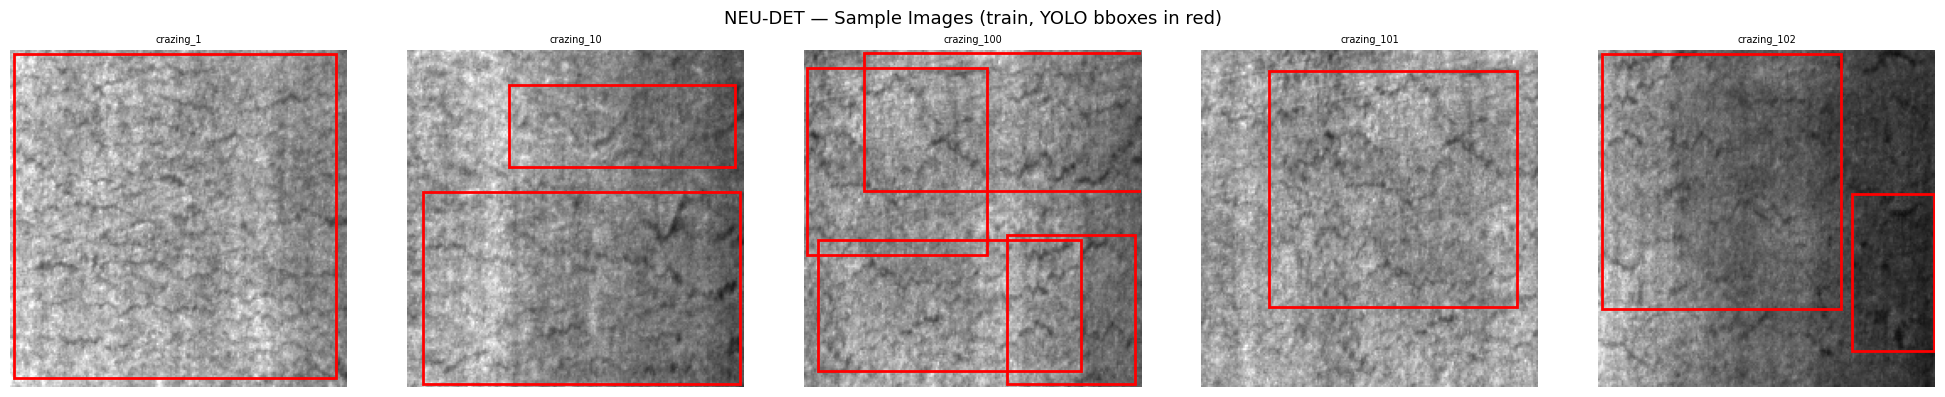

  Saved: /content/drive/MyDrive/thesis_project/results/figures/FIG_SampleGrid_NEU-DET.png


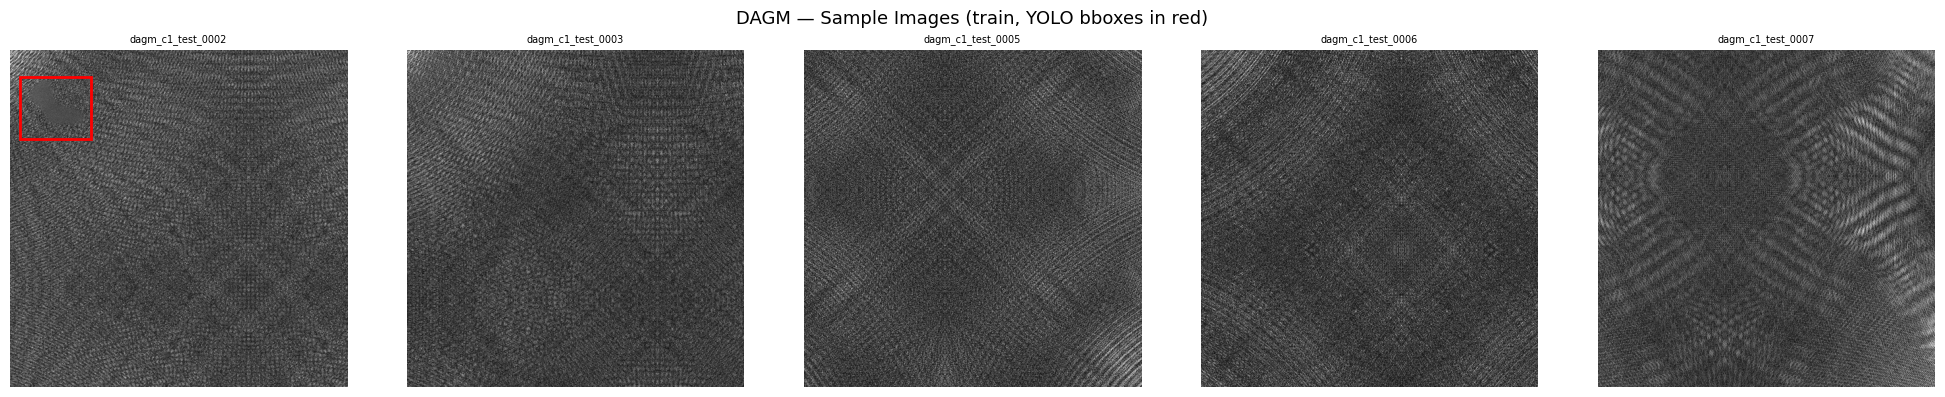

  Saved: /content/drive/MyDrive/thesis_project/results/figures/FIG_SampleGrid_DAGM.png


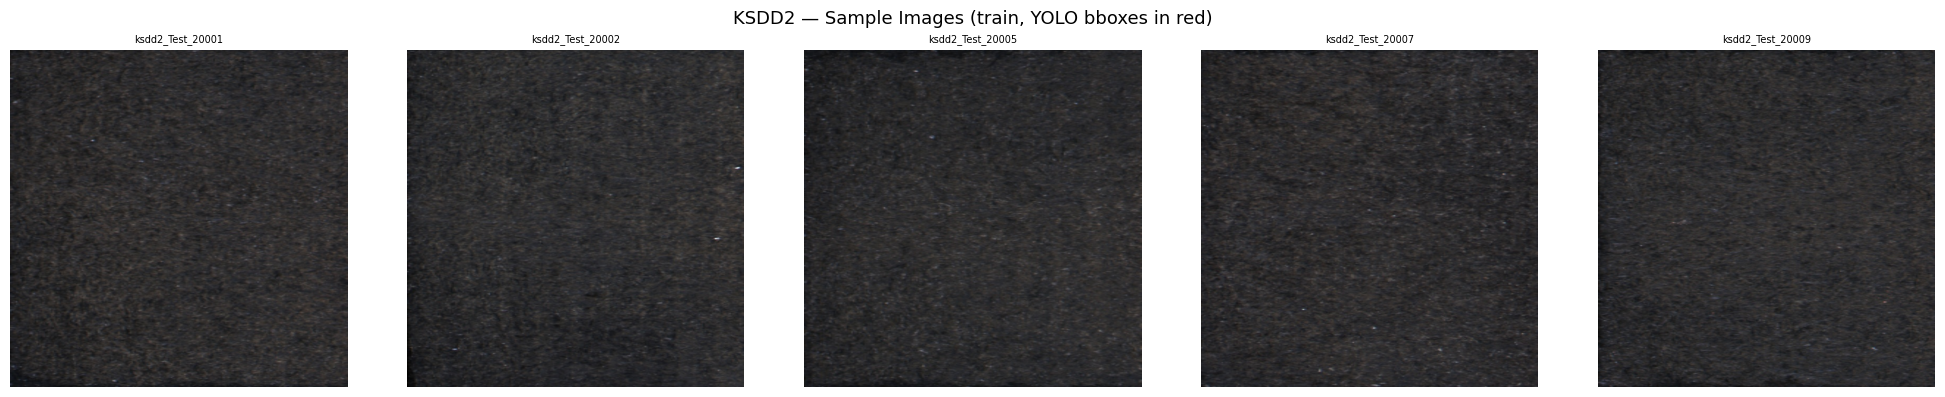

  Saved: /content/drive/MyDrive/thesis_project/results/figures/FIG_SampleGrid_KSDD2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5-B: Sample image grids with YOLO bounding box overlays
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

def draw_yolo_boxes(ax, img_bgr, lbl_path, color='red'):
    h, w = img_bgr.shape[:2]
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    lbl_p = pathlib.Path(lbl_path)
    if lbl_p.exists() and lbl_p.stat().st_size > 0:
        for line in lbl_p.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h
            rect = mpatches.Rectangle((x1, y1), bw*w, bh*h,
                                       linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
    ax.axis('off')

def save_sample_grid(ds_name, ds_dir, n_samples=5):
    img_dir = pathlib.Path(ds_dir) / 'images' / 'train'
    lbl_dir = pathlib.Path(ds_dir) / 'labels' / 'train'
    if not img_dir.is_dir():
        print(f'  {ds_name}: images/train not found')
        return

    imgs = sorted(img_dir.glob('*.jpg'))[:n_samples]
    if not imgs:
        print(f'  {ds_name}: no images found')
        return

    fig, axes = plt.subplots(1, len(imgs), figsize=(4*len(imgs), 4))
    if len(imgs) == 1:
        axes = [axes]
    fig.suptitle(f'{ds_name} — Sample Images (train, YOLO bboxes in red)', fontsize=13)

    for ax, img_path in zip(axes, imgs):
        img = cv2.imread(str(img_path))
        if img is None:
            ax.axis('off')
            continue
        lbl_path = lbl_dir / f'{img_path.stem}.txt'
        draw_yolo_boxes(ax, img, lbl_path)
        ax.set_title(img_path.stem[:18], fontsize=7)

    plt.tight_layout()
    out = f'{BASE}/results/figures/FIG_SampleGrid_{ds_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out}')

print('Generating sample grids...')
for ds_name, ds_dir in [('NEU-DET', NEU_DRIVE), ('DAGM', DAGM_DRIVE), ('KSDD2', KSDD2_DRIVE)]:
    save_sample_grid(ds_name, ds_dir)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5-C: YOLO data.yaml sanity check
# ═══════════════════════════════════════════════════════════════════════════════
# Verify YAML is valid and all referenced directories exist
# Full YOLO model.val() check is deferred to Notebook 02 (avoids loading GPU model here)
import yaml

print('=== data.yaml sanity check ===')
all_ok = True

for ds_name, ds_dir in [('NEU-DET', NEU_DRIVE), ('DAGM', DAGM_DRIVE), ('KSDD2', KSDD2_DRIVE)]:
    yaml_path = f'{ds_dir}/data.yaml'
    if not os.path.exists(yaml_path):
        print(f'  {ds_name}: MISSING data.yaml')
        all_ok = False
        continue

    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)

    ok = True
    for split in ['train', 'val', 'test']:
        split_dir = f"{ds_dir}/{cfg.get(split, split)}"
        n = len(list(pathlib.Path(split_dir).glob('*.jpg'))) if os.path.isdir(split_dir) else 0
        if n == 0:
            print(f'    {split}: EMPTY or missing')
            ok = False
    status = 'OK' if ok else 'ISSUES'
    print(f'  {ds_name}: nc={cfg["nc"]} names={cfg["names"]} [{status}]')
    all_ok = all_ok and ok

print()
if all_ok:
    print('All data.yaml files valid. Ready for Notebook 02.')
else:
    print('Some issues found — check warnings above before running Notebook 02.')

=== data.yaml sanity check ===
  NEU-DET: nc=6 names=['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratched'] [OK]
  DAGM: nc=1 names=['defect'] [OK]
  KSDD2: nc=1 names=['defect'] [OK]

All data.yaml files valid. Ready for Notebook 02.


---
# Section 6 — Checkpoint & Summary

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Save checkpoint JSON + print final summary
# ═══════════════════════════════════════════════════════════════════════════════
import json
from datetime import datetime

# Re-count for checkpoint
def split_counts(ds_dir):
    return {
        sp: count_images(ds_dir, sp)
        for sp in ['train', 'val', 'test']
    }

checkpoint = {
    'notebook': '01_data_download_and_preprocessing',
    'completed': True,
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'seed': SEED,
    'split_ratios': {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'datasets': {
        'NEU-DET': {
            'nc': 6,
            'classes': ['crazing', 'inclusion', 'patches', 'pitted_surface',
                        'rolled_in_scale', 'scratched'],
            'annotation': 'PASCAL VOC XML → YOLO format',
            'task': 'multi-class detection + classification',
            'splits': split_counts(NEU_DRIVE),
        },
        'DAGM': {
            'nc_detection': 1,
            'nc_classification': 2,
            'classes_used': DAGM_CLASSES_USED,
            'annotation': 'mask PNG → cv2.findContours → YOLO format',
            'task': 'binary detection + classification',
            'splits': split_counts(DAGM_DRIVE),
        },
        'KSDD2': {
            'nc_detection': 1,
            'nc_classification': 2,
            'annotation': 'pixel mask → cv2.findContours → YOLO format',
            'task': 'binary detection + classification (imbalanced)',
            'class_weights': f'{BASE}/dataset_metadata/ksdd2_class_weights.json',
            'splits': split_counts(KSDD2_DRIVE),
        },
    },
    'transforms': {
        'yolo_augmentation': 'Ultralytics built-in (mosaic, mixup, hsv, flips, scale)',
        'cnn_train': 'Resize(256)→RandomResizedCrop(224)→HFlip→VFlip→Rotation(15)→ColorJitter→GaussianBlur→ToTensor→Normalize(ImageNet)',
        'cnn_val': 'Resize(224)→ToTensor→Normalize(ImageNet)',
    },
    'outputs': {
        'detection_labels': 'datasets/{name}/labels/{split}/*.txt  (YOLO format)',
        'data_yamls': 'datasets/{name}/data.yaml',
        'classification': 'datasets/{name}/classification/{split}/{class_name}/*.jpg',
        'metadata_csvs': 'dataset_metadata/{neu_detection,neu_classification,dagm,ksdd2}_splits.csv',
        'class_weights': 'dataset_metadata/ksdd2_class_weights.json',
        'sample_grids': 'results/figures/FIG_SampleGrid_{NEU-DET,DAGM,KSDD2}.png',
    },
    'next_steps': [
        'Run 02_yolo_detection_training.ipynb — trains 9 YOLO models (3 sizes × 3 datasets)',
        'Run 03_cnn_classification_training.ipynb — trains 9 CNN models (3 archs × 3 datasets)',
    ]
}

ckpt_path = f'{BASE}/checkpoints/notebook01_status.json'
pathlib.Path(ckpt_path).write_text(json.dumps(checkpoint, indent=2))

print('=' * 65)
print('  NOTEBOOK 01 COMPLETE')
print('=' * 65)
print(f'  Checkpoint: {ckpt_path}')
print()
print('  OUTPUTS:')
for ds_name, ds_dir in [('NEU-DET', NEU_DRIVE), ('DAGM', DAGM_DRIVE), ('KSDD2', KSDD2_DRIVE)]:
    counts = split_counts(ds_dir)
    total = sum(counts.values())
    print(f'    {ds_name}: {total} images  (train={counts["train"]}, val={counts["val"]}, test={counts["test"]})')
print()
print('  NEXT: Run 02_yolo_detection_training.ipynb')
print('        Run 03_cnn_classification_training.ipynb')
print('=' * 65)

/tmp/ipython-input-100756768.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


  NOTEBOOK 01 COMPLETE
  Checkpoint: /content/drive/MyDrive/thesis_project/checkpoints/notebook01_status.json

  OUTPUTS:
    NEU-DET: 1550 images  (train=1085, val=232, test=233)
    DAGM: 6900 images  (train=4830, val=1035, test=1035)
    KSDD2: 5715 images  (train=4667, val=545, test=503)

  NEXT: Run 02_yolo_detection_training.ipynb
        Run 03_cnn_classification_training.ipynb
